<a href="https://colab.research.google.com/github/baotam27/DeepLearning/blob/main/Tuan2_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANN -  ARTIFICIAL NEURAL NETWORK

3.1. Nạp thư viện

In [9]:
#install required libraries
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense

# Cai dat va nap dung thu vien wrapper moi cho Scikit-Learn
!pip install scikeras
from scikeras.wrappers import KerasClassifier

from keras.layers import Dropout
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

3.2. Tải bộ dữ liệu

In [6]:
#tải bộ mnist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


3.3. Xử lý dữ liệu

In [10]:
#reshape data from 3-D to 2-D array
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

#feature scaling
minmax = MinMaxScaler()

X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


3.4. Trực quan hóa dữ liệu

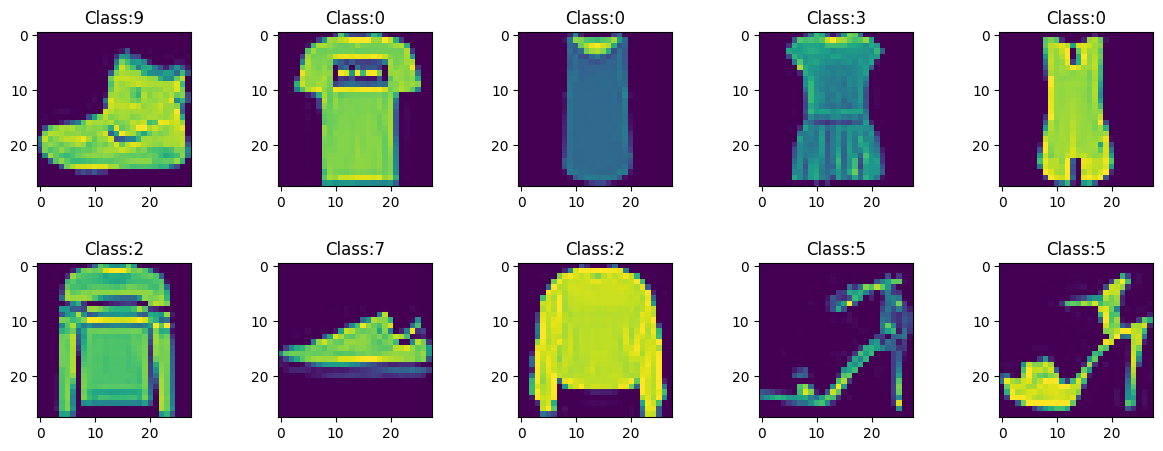

In [11]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

3.5. Xây dựng mô hình học ANN

In [12]:
#initial ANN model
fashion_model = Sequential()

#add first hidden layer
fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

#add output layer
fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

#compile neural network
fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#model summary
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

3.6. Huấn luyện ANN model

In [13]:
model_fit = fashion_model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8218 - loss: 0.5075 - val_accuracy: 0.8528 - val_loss: 0.4087
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8662 - loss: 0.3685 - val_accuracy: 0.8525 - val_loss: 0.4004
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8787 - loss: 0.3315 - val_accuracy: 0.8792 - val_loss: 0.3240
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.8868 - loss: 0.3058 - val_accuracy: 0.8757 - val_loss: 0.3373
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8946 - loss: 0.2867 - val_accuracy: 0.8810 - val_loss: 0.3380
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8992 - loss: 0.2709 - val_accuracy: 0.8852 - val_loss: 0.3249
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9047 - loss: 0.2565 - val_accuracy: 0.8843 - val_loss: 0.3138
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9081 - loss: 0.

3.7. Đánh giá ANN model

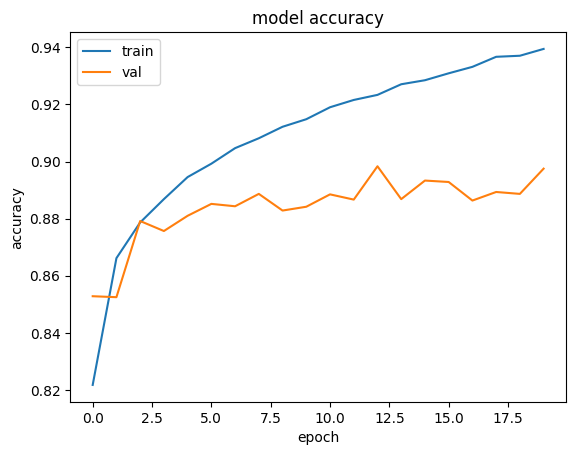

In [14]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

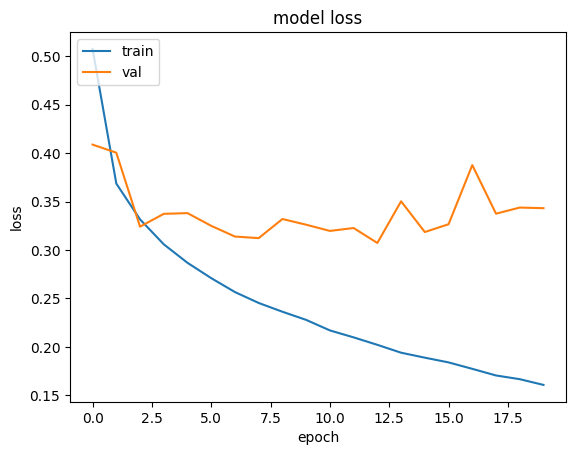

In [15]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

3.8. Dự báo ảnh mới

In [16]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
4 4


3.9. Đọc tập dữ liệu từ file

In [31]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

print("Đang khởi tạo và tự động chuyển đổi dữ liệu sang file CSV...")

# 1. Tải bộ dữ liệu gốc có sẵn từ hệ thống TensorFlow
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.fashion_mnist.load_data()

# 2. Reshape ma trận ảnh (60000, 28, 28) thành mảng phẳng 2 chiều (60000, 784)
X_train_flat = X_train_raw.reshape(60000, 784)
X_test_flat = X_test_raw.reshape(10000, 784)

# 3. Chuyển đổi sang cấu trúc DataFrame của Pandas (Cột đầu tiên là nhãn label, theo sau là 784 điểm ảnh)
df_train = pd.DataFrame(X_train_flat)
df_train.insert(0, 'label', y_train_raw) # Đẩy cột label lên đầu y hệt file mẫu

df_test = pd.DataFrame(X_test_flat)
df_test.insert(0, 'label', y_test_raw)

# 4. Đảm bảo thư mục đích tồn tại và lưu dữ liệu thành file CSV thực tế
os.makedirs('/content/sample_data', exist_ok=True)
df_train.to_csv('/content/sample_data/fashion-mnist_train.csv', index=False)
df_test.to_csv('/content/sample_data/fashion-mnist_test.csv', index=False)

print(" Đã tạo thành công 2 file CSV thật vào đúng đường dẫn hệ thống!")

Đang khởi tạo và tự động chuyển đổi dữ liệu sang file CSV...
 Đã tạo thành công 2 file CSV thật vào đúng đường dẫn hệ thống!


In [32]:
mnist_train_path = '/content/sample_data/fashion-mnist_train.csv'
mnist_test_path = '/content/sample_data/fashion-mnist_test.csv'
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)
print(mnist_train.head())
print(mnist_train.shape)

   label  0  1  2  3  4  5  6  7   8  ...  774  775  776  777  778  779  780  \
0      9  0  0  0  0  0  0  0  0   0  ...    0    0    0    0    0    0    0   
1      0  0  0  0  0  0  1  0  0   0  ...  119  114  130   76    0    0    0   
2      0  0  0  0  0  0  0  0  0   0  ...    0    0    1    0    0    0    0   
3      3  0  0  0  0  0  0  0  0  33  ...    0    0    0    0    0    0    0   
4      0  0  0  0  0  0  0  0  0   0  ...    0    0    0    0    0    0    0   

   781  782  783  
0    0    0    0  
1    0    0    0  
2    0    0    0  
3    0    0    0  
4    0    0    0  

[5 rows x 785 columns]
(60000, 785)


In [33]:
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]
print(X_train.shape)

y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

(60000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [21]:
import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense

In [22]:
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8256 - loss: 0.4936
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8660 - loss: 0.3674
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8787 - loss: 0.3288
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8880 - loss: 0.3039
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8921 - loss: 0.2868
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8991 - loss: 0.2713
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9026 - loss: 0.2588
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9074 - loss: 0.2479
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9104 - loss: 0.2378
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9147 - loss: 0.2270
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9178 - loss: 0.2196
Epoch 12/30
1875/1875

In [24]:
print(np.argmax(model.predict(X_test)[0]), y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9


In [36]:
import os
import cv2
import numpy as np
import tensorflow as tf

print("Đang tự động khởi tạo file ảnh 'dress.jpg' vào thư mục sample_data...")

# 1. Đảm bảo thư mục sample_data tồn tại
os.makedirs('/content/sample_data', exist_ok=True)

# 2. Lấy thử 1 tấm ảnh ngẫu nhiên thuộc nhóm Quần/Áo từ bộ dữ liệu gốc để lưu thành file ảnh thật
(X_train_raw, y_train_raw), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

# Tìm vị trí tấm ảnh đầu tiên thuộc lớp số 3 (Dress - Váy) hoặc lớp số 0 (T-shirt)
idx = np.where(y_train_raw == 3)[0][0]
sample_img = X_train_raw[idx]

# 3. Sử dụng OpenCV để lưu mảng ma trận số này thành file ảnh 'dress.jpg' thực tế
cv2.imwrite('/content/sample_data/dress.jpg', sample_img)

print(" Đã tạo thành công file ảnh thật tại: /content/sample_data/dress.jpg")

Đang tự động khởi tạo file ảnh 'dress.jpg' vào thư mục sample_data...
 Đã tạo thành công file ảnh thật tại: /content/sample_data/dress.jpg


In [37]:
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress.jpg', color_mode='grayscale', target_size=img_size)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
3
